![Logo UOC](https://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/logotips/logo-UOC-2linies.png)

# TFG - Inteligencia Artificial
Enero de 2026

## Predicción de Respuesta a Tratamientos Oncológicos Basada en el Perfil Genético Mediante Técnicas de Aprendizaje Automático (ML) e Identificación de Genes Candidatos a Biomarcador Usando Técnicas de Explicabilidad (XAI) y Cuantificación de la Incertidumbre (UQ)

---

#### Pablo Vázquez Rodríguez
##### Grado en Ingeniería Informática
##### Inteligencia Artificial

#### Dra. María Moreno de Castro
#### Dr. Friman Sánchez

---

## Modelado (Paso 3): Calibración de los modelos

Como ya se comentó en el documento de exploración y preparación de datos durante el modelado se harán estas tareas:
1. Selección de características supervisada
2. Entrenamiento de modelos
3. Calibración del modelo
4. Análisis y selección del modelo optimizado

Durante la primera tarea se realiza una selección de genes basada en modelos de regresión logística, Random Forest, XGBoost y CatBoost, con filtrado no supervisado mediante Elbow/K-Means.

Durante la segunda tarea, se entrenan los modelos de nuevo esta vez sobre el conjunto que contiene sólo a los genes seleccionados. 

Durante la tercera tarea, tras el entrenamiento, se calibran los modelos.

Durante la cuarta tarea se hace un análisis de los modelos obtenidos, se valora su rendimiento, incertidumbre y se elige el modelo óptimo para los objetivos del proyecto.

## 0. Operaciones previas

### Carga de librerías necesarias

In [1]:
import pandas as pd
import numpy as np
import optuna
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    f1_score, roc_curve, auc, accuracy_score, 
    precision_score, recall_score, roc_auc_score,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from venn_abers import VennAbers
import matplotlib.pyplot as plt
from aux.ml_core import metrics as auxmetrics, calibration

### Configuraciones iniciales

In [2]:
# Random generator de numpy con seed para reproducibilidad en el notebook
rng_seed = 19293
rng = np.random.default_rng(seed=rng_seed)

In [3]:
# Carga de los datasets
df_full = pd.read_csv("./data/final/full_top_significance_reduced_feat.csv")
df_train = pd.read_csv("./data/final/train_reduced_feat.csv")
df_test = pd.read_csv("./data/final/test_reduced_feat.csv")
df_cal = pd.read_csv("./data/final/cal_reduced_feat.csv")
df_scaled_train = pd.read_csv("./data/final/scaled_train_reduced_feat.csv")
df_scaled_test = pd.read_csv("./data/final/scaled_test_reduced_feat.csv")
df_scaled_cal = pd.read_csv("./data/final/scaled_cal_reduced_feat.csv")

In [4]:
# Carga de los estudios realizados
optuna_storage_path = "sqlite:///./data/optuna_studies/studies.db"

logreg_study_name = "2025-12-23T05:30:42.848671_best_logreg_model_study"
logreg_study = optuna.load_study(study_name=logreg_study_name, storage=optuna_storage_path)

rf_study_name = "2025-12-23T05:36:20.628736_best_rf_model_study"
rf_study = optuna.load_study(study_name=rf_study_name, storage=optuna_storage_path)

xgboost_study_name = "2025-12-23T05:45:06.437146_best_xgboost_model_study"
xgboost_study = optuna.load_study(study_name=xgboost_study_name, storage=optuna_storage_path)

catboost_study_name = "2025-12-23T05:49:50.187119_best_catboost_model_study"
catboost_study = optuna.load_study(study_name=catboost_study_name, storage=optuna_storage_path)

In [5]:
# Carga de los modelos entrenados
logreg_model = joblib.load("./data/best_models/best_logreg_model.joblib")
rf_model = joblib.load("./data/best_models/best_rf_model.joblib")
xgboost_model = joblib.load("./data/best_models/best_xgboost_model.joblib")
catboost_model = joblib.load("./data/best_models/best_catboost_model.joblib")

In [6]:
# VARIABLES ÚTILES

# Nombres de las columnas de genes
gene_columns = df_full.columns.difference(["Sample_id", "Response"])

In [7]:
# Datos de entrenamiento
X_train = df_scaled_train.drop(columns=["Response", "Sample_id"])
y_train_orig = df_scaled_train["Response"]

# Datos de test
X_test = df_scaled_test.drop(columns=["Response", "Sample_id"])
y_test_orig = df_scaled_test["Response"]

# Datos de calibración
X_cal = df_scaled_cal.drop(columns=["Response", "Sample_id"])
y_cal_orig = df_scaled_cal["Response"]

# Clases objetivo a 0/1: Non_response=0, Response=1
le = LabelEncoder()
y_train = le.fit_transform(y_train_orig)
y_test = le.fit_transform(y_test_orig)
y_cal = le.fit_transform(y_cal_orig)

# Mostrar mapeo de clases
for i, label in enumerate(le.classes_): print(f"{i}: {label}")

0: Non_response
1: Response


## 1. Calibración de los modelos

---
**Regresión Logística**

**Valores obtenidos**

**Estudio (Optuna)**: 2025-12-23T05:30:42.848671_best_logreg_model_study 

**Mejores parámetros**: {'C': 2.9572029517344083, 'l1_ratio': 0.8695927259963505} 

**F1**: 0.5933910528325129 

**Intervalo de scores F1**:  (0.5775862068965517, 0.6111111111111112)

---
**Random Forest**

**Valores obtenidos**

**Estudio (Optuna)**: 2025-12-23T05:36:20.628736_best_rf_model_study 

**Mejores parámetros**: {'n_estimators': 233, 'max_depth': 17, 'max_features': 0.2, 'min_samples_split': 11, 'min_samples_leaf': 2} 

**F1**: 0.6456096926833015 

**Intervalo de scores F1**:  (0.6204081632653061, 0.6864406779661016)

---
**XGBoost**

**Valores obtenidos**

**Estudio (Optuna)**: 2025-12-23T05:45:06.437146_best_xgboost_model_study 

**Mejores parámetros**: {'n_estimators': 645, 'max_depth': 6, 'learning_rate': 0.04269416688188391, 'min_child_weight': 5, 'reg_alpha': 0.0010122171661582713, 'reg_lambda': 0.007249544721553679, 'subsample': 0.5020579643247725, 'colsample_bytree': 0.6033017565343983, 'gamma': 4.448209828162774} 

**F1**: 0.6396684818467095 

**Intervalo de scores F1**:  (0.6136363636363636, 0.684931506849315)

---
**CatBoost**

**Estudio (Optuna)**: 2025-12-23T05:49:50.187119_best_catboost_model_study 

**Mejores parámetros**: {'iterations': 649, 'depth': 8, 'learning_rate': 0.06953212502022214, 'l2_leaf_reg': 1.0047858272648311, 'border_count': 47, 'rsm': 0.8226220591598365} 

**F1**: 0.6510875816428066 

**Intervalo de scores F1**:  (0.61003861003861, 0.68)

### 1.1 Qué es calibrar y por qué calibrar

La calibración de un modelo supervisado consiste en evaluar y, en caso necesario, corregir la correspondencia entre las probabilidades predichas y la frecuencia real del evento que se desea estimar. Un modelo está bien calibrado cuando, por ejemplo, entre las instancias a las que asigna una probabilidad del 0.7, aproximadamente el 70 % pertenece efectivamente a la clase positiva. Este análisis no modifica la capacidad discriminativa del modelo, es decir, su habilidad para ordenar correctamente los casos positivos y negativos, sino que ajusta la interpretación probabilística de sus salidas.

Calibrar un modelo es especialmente relevante en contextos donde las probabilidades predichas se utilizan para apoyar decisiones clínicas, priorizar intervenciones o establecer umbrales de clasificación. Modelos con buena discriminación pero mala calibración pueden inducir a decisiones erróneas al sobreestimar o infraestimar el riesgo real. La calibración permite, por tanto, obtener predicciones más fiables y comparables entre algoritmos, facilitando una interpretación robusta y una toma de decisiones informada.

### 1.2 Calibradores que se evaluarán

La calibración se evaluará utilizando tres métodos complementarios: Platt Scaling, Isotonic Regression y Venn–ABERS. Platt Scaling aplica una transformación logística sobre las probabilidades predichas y suele ofrecer buenos resultados cuando la relación entre las probabilidades no calibradas y las verdaderas es aproximadamente sigmoidal. Es un método simple, eficiente y poco propenso al sobreajuste, aunque puede resultar insuficiente cuando la distorsión de las probabilidades es más compleja. Por su parte, Isotonic Regression es un calibrador no paramétrico que ajusta una función monótona por tramos, permitiendo capturar relaciones más flexibles entre las probabilidades predichas y las observadas. Su principal fortaleza es la capacidad de corregir patrones de mala calibración arbitrarios, aunque a costa de un mayor riesgo de sobreajuste cuando el tamaño muestral es limitado.

El método Venn–ABERS se incluye como alternativa más robusta y conservadora, especialmente adecuada en contextos donde la fiabilidad probabilística es crítica. A diferencia de los calibradores tradicionales, Venn–ABERS construye dos modelos de calibración independientes mediante regresión isotónica: uno asumiendo que la instancia pertenece a la clase positiva y otro asumiendo que pertenece a la clase negativa. A partir de estas dos funciones se generan intervalos de probabilidad válidos bajo supuestos mínimos, lo que permite cuantificar explícitamente la incertidumbre asociada a cada predicción. Esta propiedad resulta especialmente valiosa en escenarios clínicos, donde la interpretación probabilística debe ser prudente, estable y fiable incluso en presencia de tamaños muestrales reducidos o patrones de riesgo complejos. En conjunto, la comparación de estos tres calibradores permitirá evaluar el equilibrio entre flexibilidad, estabilidad y robustez, y seleccionar el método más adecuado para garantizar probabilidades clínicamente interpretables.

### 1.3 Métricas de calibración

Calibramos los modelos con: Platt Scaling, Isotonic Regresion y Venn-ABERS usando el conjunto de calibración

**LOGISTIC REGRESSION**

In [8]:
va_logreg_model, platt_logreg_model, isotonic_logreg_model = calibration.calibrate_models(logreg_model, X_cal, y_cal)

/home/pablo_uoc/UOC/TFG_AI/.venv/lib/python3.12/site-packages/venn_abers/venn_abers.py:104: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:


In [9]:
calibrated_logreg_models = {
    "va": va_logreg_model,
    "platt": platt_logreg_model,
    "isotonic": isotonic_logreg_model
}
logreg_calibration_metrics = calibration.evaluate_calibrated_models(logreg_model, calibrated_logreg_models, X_test, y_test)
print("###################\nLOGISTIC REGRESSION\n###################")
for model_name, metrics in logreg_calibration_metrics.items():
    print(f"\n=== {model_name.upper()} ===")
    print(f"Brier Score: {metrics['brier']:.3f}")
    print(f"LogLoss:     {metrics['logloss']:.3f}")
    print(f"ECE:         {metrics['ece']:.3f}")
    print(f"F1 Score:    {metrics['f1']:.3f}")
    print(f"F1 Umbral:   {metrics['threshold']:.3f}")

###################
LOGISTIC REGRESSION
###################

=== BASE ===
Brier Score: 0.216
LogLoss:     0.622
ECE:         0.120
F1 Score:    0.645
F1 Umbral:   0.421

=== VA ===
Brier Score: 0.206
LogLoss:     0.601
ECE:         0.046
F1 Score:    0.623
F1 Umbral:   0.324

=== PLATT ===
Brier Score: 0.204
LogLoss:     0.594
ECE:         0.084
F1 Score:    0.645
F1 Umbral:   0.298

=== ISOTONIC ===
Brier Score: 0.207
LogLoss:     0.835
ECE:         0.053
F1 Score:    0.623
F1 Umbral:   0.312


**RANDOM FOREST**

In [10]:
va_rf_model, platt_rf_model, isotonic_rf_model = calibration.calibrate_models(rf_model, X_cal, y_cal)

In [11]:
calibrated_rf_models = {
    "va": va_rf_model,
    "platt": platt_rf_model,
    "isotonic": isotonic_rf_model
}
rf_calibration_metrics = calibration.evaluate_calibrated_models(rf_model, calibrated_rf_models, X_test, y_test)
print("#############\nRANDOM FOREST\n#############")
for model_name, metrics in rf_calibration_metrics.items():
    print(f"\n=== {model_name.upper()} ===")
    print(f"Brier Score: {metrics['brier']:.3f}")
    print(f"LogLoss:     {metrics['logloss']:.3f}")
    print(f"ECE:         {metrics['ece']:.3f}")
    print(f"F1 Score:    {metrics['f1']:.3f}")
    print(f"F1 Umbral:   {metrics['threshold']:.3f}")

#############
RANDOM FOREST
#############

=== BASE ===
Brier Score: 0.182
LogLoss:     0.539
ECE:         0.076
F1 Score:    0.669
F1 Umbral:   0.341

=== VA ===
Brier Score: 0.191
LogLoss:     0.564
ECE:         0.072
F1 Score:    0.631
F1 Umbral:   0.329

=== PLATT ===
Brier Score: 0.184
LogLoss:     0.549
ECE:         0.067
F1 Score:    0.669
F1 Umbral:   0.298

=== ISOTONIC ===
Brier Score: 0.189
LogLoss:     0.557
ECE:         0.060
F1 Score:    0.633
F1 Umbral:   0.325


**XGBOOST**

In [12]:
va_xgboost_model, platt_xgboost_model, isotonic_xgboost_model = calibration.calibrate_models(xgboost_model, X_cal, y_cal)

/home/pablo_uoc/UOC/TFG_AI/.venv/lib/python3.12/site-packages/venn_abers/venn_abers.py:104: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:


In [13]:
calibrated_xgboost_models = {
    "va": va_xgboost_model,
    "platt": platt_xgboost_model,
    "isotonic": isotonic_xgboost_model
}
xgboost_calibration_metrics = calibration.evaluate_calibrated_models(xgboost_model, calibrated_xgboost_models, X_test, y_test)
print("#######\nXGBOOST\n#######")
for model_name, metrics in xgboost_calibration_metrics.items():
    print(f"\n=== {model_name.upper()} ===")
    print(f"Brier Score: {metrics['brier']:.3f}")
    print(f"LogLoss:     {metrics['logloss']:.3f}")
    print(f"ECE:         {metrics['ece']:.3f}")
    print(f"F1 Score:    {metrics['f1']:.3f}")
    print(f"F1 Umbral:   {metrics['threshold']:.3f}")

#######
XGBOOST
#######

=== BASE ===
Brier Score: 0.188
LogLoss:     0.557
ECE:         0.090
F1 Score:    0.662
F1 Umbral:   0.401

=== VA ===
Brier Score: 0.188
LogLoss:     0.561
ECE:         0.083
F1 Score:    0.647
F1 Umbral:   0.396

=== PLATT ===
Brier Score: 0.186
LogLoss:     0.555
ECE:         0.057
F1 Score:    0.662
F1 Umbral:   0.333

=== ISOTONIC ===
Brier Score: 0.187
LogLoss:     0.562
ECE:         0.080
F1 Score:    0.647
F1 Umbral:   0.395


**CATBOOST**

In [14]:
va_catboost_model, platt_catboost_model, isotonic_catboost_model = calibration.calibrate_models(catboost_model, X_cal, y_cal)

In [15]:
calibrated_catboost_models = {
    "va": va_catboost_model,
    "platt": platt_catboost_model,
    "isotonic": isotonic_catboost_model
}
catboost_calibration_metrics = calibration.evaluate_calibrated_models(catboost_model, calibrated_catboost_models, X_test, y_test)
print("########\nCATBOOST\n########")
for model_name, metrics in catboost_calibration_metrics.items():
    print(f"\n=== {model_name.upper()} ===")
    print(f"Brier Score: {metrics['brier']:.3f}")
    print(f"LogLoss:     {metrics['logloss']:.3f}")
    print(f"ECE:         {metrics['ece']:.3f}")
    print(f"F1 Score:    {metrics['f1']:.3f}")
    print(f"F1 Umbral:   {metrics['threshold']:.3f}")

########
CATBOOST
########

=== BASE ===
Brier Score: 0.200
LogLoss:     0.690
ECE:         0.154
F1 Score:    0.667
F1 Umbral:   0.216

=== VA ===
Brier Score: 0.188
LogLoss:     0.560
ECE:         0.058
F1 Score:    0.664
F1 Umbral:   0.413

=== PLATT ===
Brier Score: 0.188
LogLoss:     0.560
ECE:         0.060
F1 Score:    0.667
F1 Umbral:   0.293

=== ISOTONIC ===
Brier Score: 0.188
LogLoss:     0.786
ECE:         0.052
F1 Score:    0.664
F1 Umbral:   0.407


**RESUMEN DE MÉTRICAS DE CALIBRACIÓN**

In [16]:
metrics_by_model = {
    "LogReg": logreg_calibration_metrics,
    "RandomForest": rf_calibration_metrics,
    "XGBoost": xgboost_calibration_metrics,
    "CatBoost": catboost_calibration_metrics  
}

df_metrics = calibration.build_calibration_summary(metrics_by_model)
df_metrics

,Modelo,Calibrador,Brier,LogLoss,ECE,F1,Umbral F1
0,LogReg,base,0.216,0.622,0.120,0.645,0.421
2,LogReg,platt,0.204,0.594,0.084,0.645,0.298
3,LogReg,isotonic,0.207,0.835,0.053,0.623,0.312
1,LogReg,va,0.206,0.601,0.046,0.623,0.324
4,RandomForest,base,0.182,0.539,0.076,0.669,0.341
6,RandomForest,platt,0.184,0.549,0.067,0.669,0.298
7,RandomForest,isotonic,0.189,0.557,0.060,0.633,0.325
5,RandomForest,va,0.191,0.564,0.072,0.631,0.329
8,XGBoost,base,0.188,0.557,0.090,0.662,0.401
10,XGBoost,platt,0.186,0.555,0.057,0.662,0.333


**RESUMEN DE CURVAS DE CALIBRACIÓN**

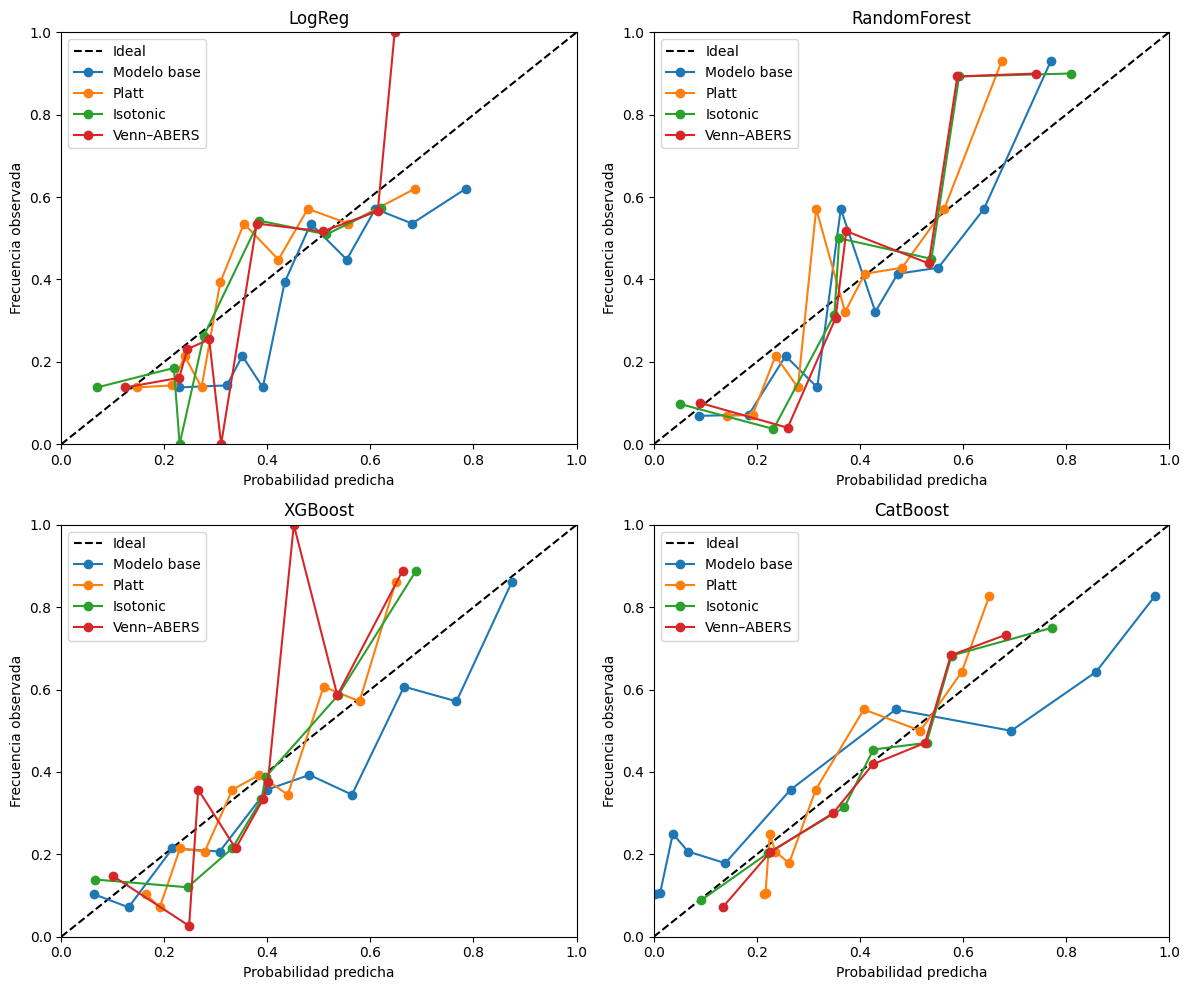

In [17]:
p_logreg   = logreg_model.predict_proba(X_test)
p_rf       = rf_model.predict_proba(X_test)
p_xgboost  = xgboost_model.predict_proba(X_test)
p_catboost = catboost_model.predict_proba(X_test)

p_logreg_platt   = platt_logreg_model.predict_proba(X_test)
p_rf_platt       = platt_rf_model.predict_proba(X_test)
p_xgboost_platt  = platt_xgboost_model.predict_proba(X_test)
p_catboost_platt = platt_catboost_model.predict_proba(X_test)

p_logreg_isotonic   = isotonic_logreg_model.predict_proba(X_test)
p_rf_isotonic       = isotonic_rf_model.predict_proba(X_test)
p_xgboost_isotonic  = isotonic_xgboost_model.predict_proba(X_test)
p_catboost_isotonic = isotonic_catboost_model.predict_proba(X_test)

p_logreg_va, _   = va_logreg_model.predict_proba(p_logreg)
p_rf_va, _       = va_rf_model.predict_proba(p_rf)
p_xgboost_va, _  = va_xgboost_model.predict_proba(p_xgboost)
p_catboost_va, _ = va_catboost_model.predict_proba(p_catboost)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

calibration.plot_calibration_curve(
    axes[0,0], y_test, p_logreg[:,1],   p_logreg_platt[:,1],   p_logreg_isotonic[:,1],   p_logreg_va[:,1],   "LogReg")
calibration.plot_calibration_curve(
    axes[0,1], y_test, p_rf[:,1],       p_rf_platt[:,1],       p_rf_isotonic[:,1],       p_rf_va[:,1],       "RandomForest")
calibration.plot_calibration_curve(
    axes[1,0], y_test, p_xgboost[:,1],  p_xgboost_platt[:,1],  p_xgboost_isotonic[:,1],  p_xgboost_va[:,1],  "XGBoost")
calibration.plot_calibration_curve(
    axes[1,1], y_test, p_catboost[:,1], p_catboost_platt[:,1], p_catboost_isotonic[:,1], p_catboost_va[:,1], "CatBoost")

plt.tight_layout()
    
# Guardar
plt.savefig("./data/figures/calibration_curves.pdf", format="pdf", bbox_inches="tight")

# Mostrar
plt.show()

### 1.4 Decision Curve Analysis (DCA)

**LOGISTIC REGRESSION**

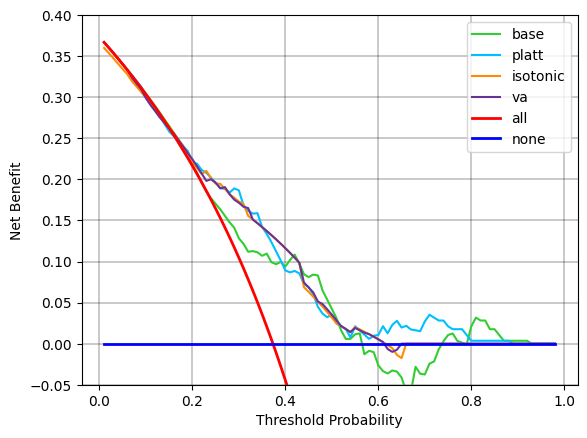

In [18]:
logreg_dca_plot = auxmetrics.decision_curve_analysis(
    logreg_model, va_logreg_model, platt_logreg_model, isotonic_logreg_model, X_test, y_test, X_cal, y_cal,
    save_path="./data/figures/logreg_dca_plot.pdf", dpi=100, y_limits=(-0.05, 0.4))

**RANDOM FOREST**

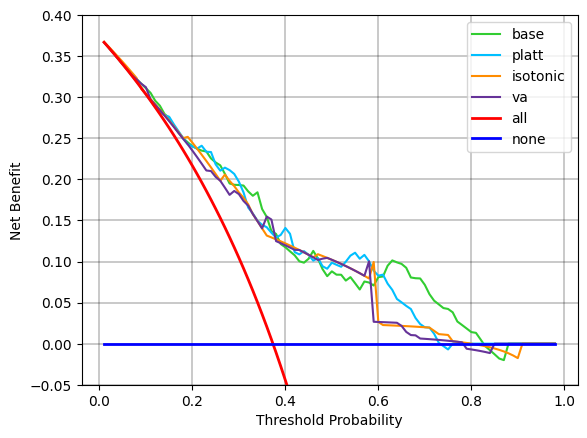

In [19]:
rf_dca_plot = auxmetrics.decision_curve_analysis(
    rf_model, va_rf_model, platt_rf_model, isotonic_rf_model, X_test, y_test, X_cal, y_cal,
    save_path="./data/figures/rf_dca_plot.pdf", dpi=100, y_limits=(-0.05, 0.4))

**XGBOOST**

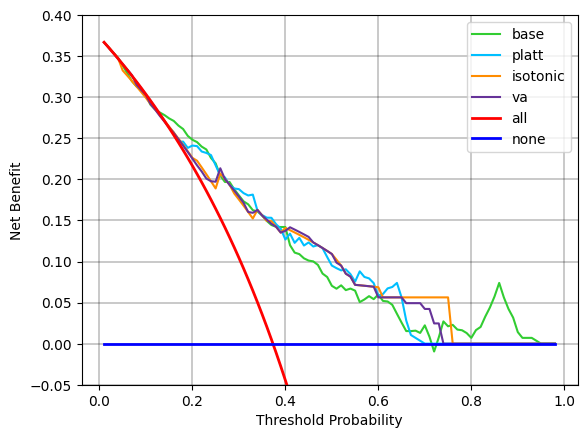

In [20]:
xgboost_dca_plot = auxmetrics.decision_curve_analysis(
    xgboost_model, va_xgboost_model, platt_xgboost_model, isotonic_xgboost_model, X_test, y_test, X_cal, y_cal,
    save_path="./data/figures/xgboost_dca_plot.pdf", dpi=100, y_limits=(-0.05, 0.4))

**CATBOOST**

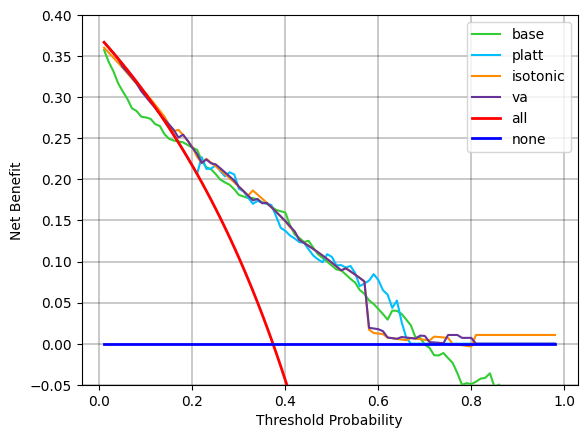

In [21]:
catboost_dca_plot = auxmetrics.decision_curve_analysis(
    catboost_model, va_catboost_model, platt_catboost_model, isotonic_catboost_model, X_test, y_test, X_cal, y_cal,
    save_path="./data/figures/catboost_dca_plot.pdf", dpi=100, y_limits=(-0.05, 0.4))

### 1.5 Cuantificación Incertidumbre con intervalos Venn-ABERS

**LOGISTIC REGRESSION**

/home/pablo_uoc/UOC/TFG_AI/.venv/lib/python3.12/site-packages/venn_abers/venn_abers.py:104: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:


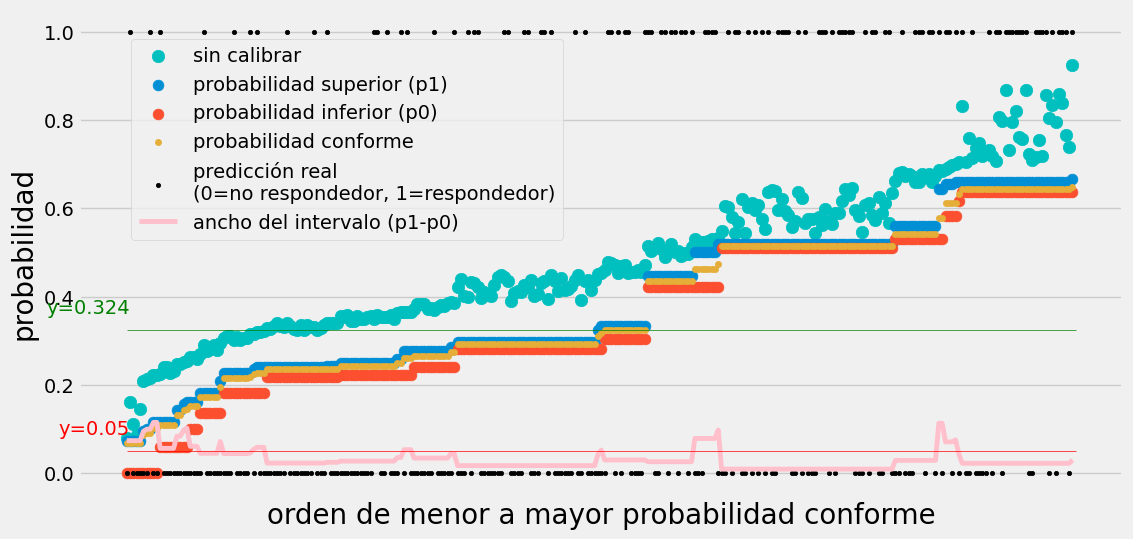

In [22]:
logreg_model_venn_abers_intervals_info = calibration.venn_abers_intervals(
    logreg_model, X_test, y_test, X_cal, y_cal, min_interval_width_filter=0.0, decision_threshold=0.324, point_size=10)

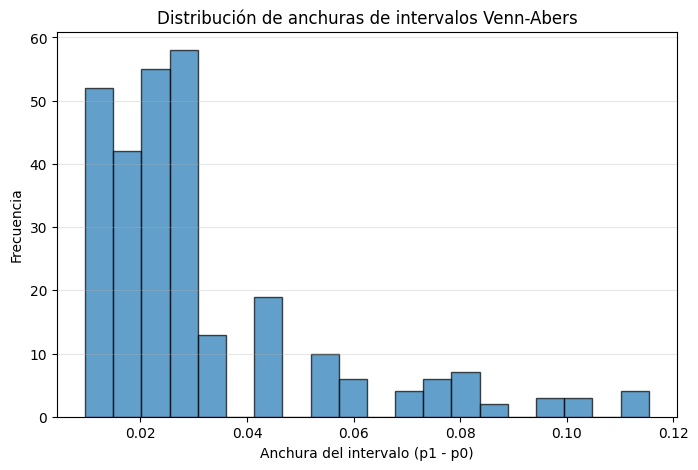

In [23]:
# Histograma de frecuencias de cada ancho de intervalo
plt.figure(figsize=(8, 5))
plt.hist(logreg_model_venn_abers_intervals_info["width"], bins=20, edgecolor='black', alpha=0.7)
plt.xlabel("Anchura del intervalo (p1 - p0)")
plt.ylabel("Frecuencia")
plt.title("Distribución de anchuras de intervalos Venn-Abers")
plt.grid(axis='y', alpha=0.3)
plt.show()

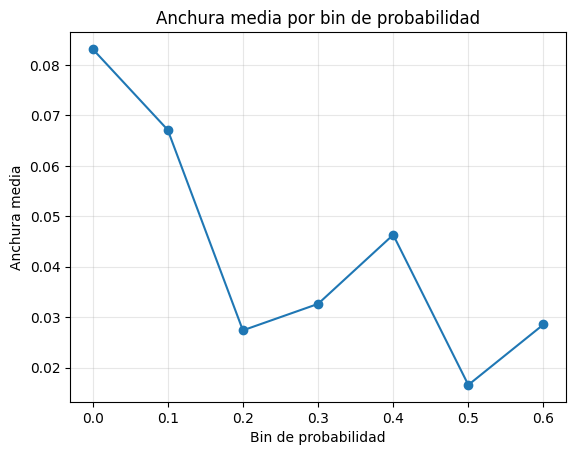

In [24]:
bins = np.linspace(0, 1, 11)
bin_idx = np.digitize(logreg_model_venn_abers_intervals_info["p"], bins)

mean_widths = [logreg_model_venn_abers_intervals_info["width"][bin_idx == i].mean() for i in range(1, len(bins))]

plt.plot(bins[:-1], mean_widths, marker='o')
plt.xlabel("Bin de probabilidad")
plt.ylabel("Anchura media")
plt.title("Anchura media por bin de probabilidad")
plt.grid(alpha=0.3)
plt.show()


**RANDOM FOREST**

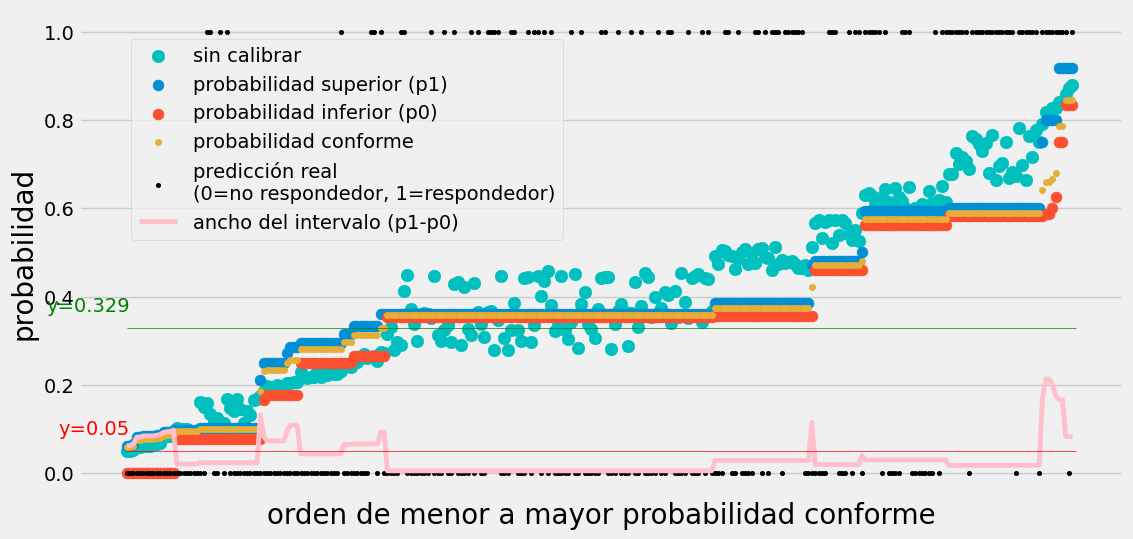

In [25]:
rf_model_venn_abers_intervals_info = calibration.venn_abers_intervals(
    rf_model, X_test, y_test, X_cal, y_cal, min_interval_width_filter=0.0, decision_threshold=0.329, point_size=10)

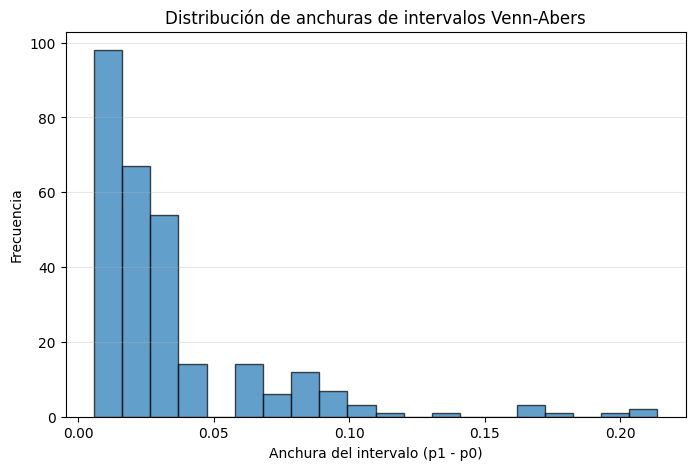

In [26]:
# Histograma de frecuencias de cada ancho de intervalo
plt.figure(figsize=(8, 5))
plt.hist(rf_model_venn_abers_intervals_info["width"], bins=20, edgecolor='black', alpha=0.7)
plt.xlabel("Anchura del intervalo (p1 - p0)")
plt.ylabel("Frecuencia")
plt.title("Distribución de anchuras de intervalos Venn-Abers")
plt.grid(axis='y', alpha=0.3)
plt.show()

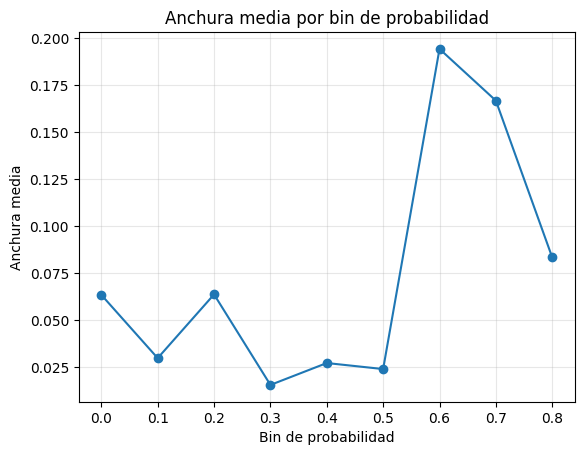

In [27]:
bins = np.linspace(0, 1, 11)
bin_idx = np.digitize(rf_model_venn_abers_intervals_info["p"], bins)

mean_widths = [rf_model_venn_abers_intervals_info["width"][bin_idx == i].mean() for i in range(1, len(bins))]

plt.plot(bins[:-1], mean_widths, marker='o')
plt.xlabel("Bin de probabilidad")
plt.ylabel("Anchura media")
plt.title("Anchura media por bin de probabilidad")
plt.grid(alpha=0.3)
plt.show()


**XGBOOST**

/home/pablo_uoc/UOC/TFG_AI/.venv/lib/python3.12/site-packages/venn_abers/venn_abers.py:104: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:


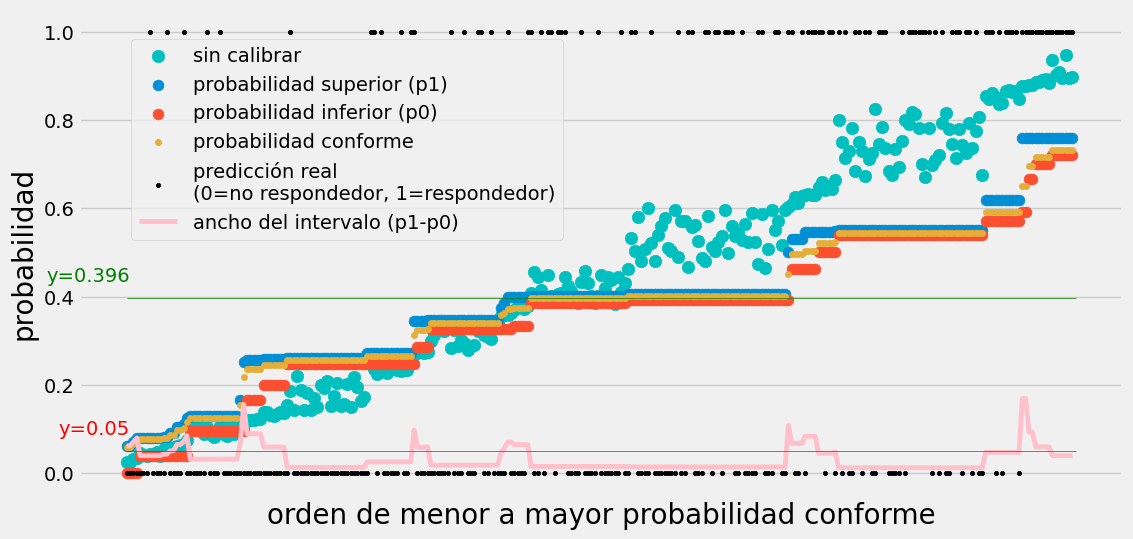

In [44]:
xgboost_model_venn_abers_intervals_info = calibration.venn_abers_intervals(
    xgboost_model, X_test, y_test, X_cal, y_cal, min_interval_width_filter=0.0, decision_threshold=0.396, point_size=10,
    save_path='./data/figures/xgboost_venn_abers_intervals.pdf')

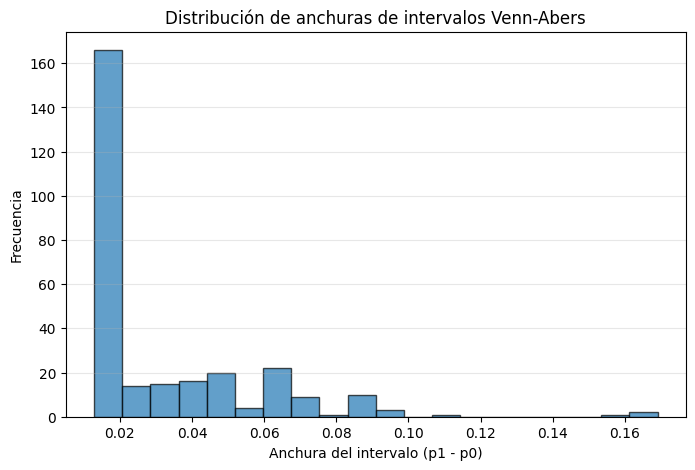

In [29]:
# Histograma de frecuencias de cada ancho de intervalo
plt.figure(figsize=(8, 5))
plt.hist(xgboost_model_venn_abers_intervals_info["width"], bins=20, edgecolor='black', alpha=0.7)
plt.xlabel("Anchura del intervalo (p1 - p0)")
plt.ylabel("Frecuencia")
plt.title("Distribución de anchuras de intervalos Venn-Abers")
plt.grid(axis='y', alpha=0.3)
plt.show()

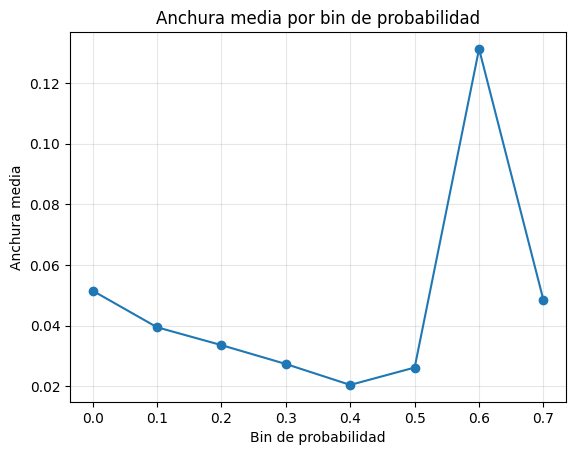

In [30]:
bins = np.linspace(0, 1, 11)
bin_idx = np.digitize(xgboost_model_venn_abers_intervals_info["p"], bins)

mean_widths = [xgboost_model_venn_abers_intervals_info["width"][bin_idx == i].mean() for i in range(1, len(bins))]

plt.plot(bins[:-1], mean_widths, marker='o')
plt.xlabel("Bin de probabilidad")
plt.ylabel("Anchura media")
plt.title("Anchura media por bin de probabilidad")
plt.grid(alpha=0.3)
plt.show()


**CATBOOST**

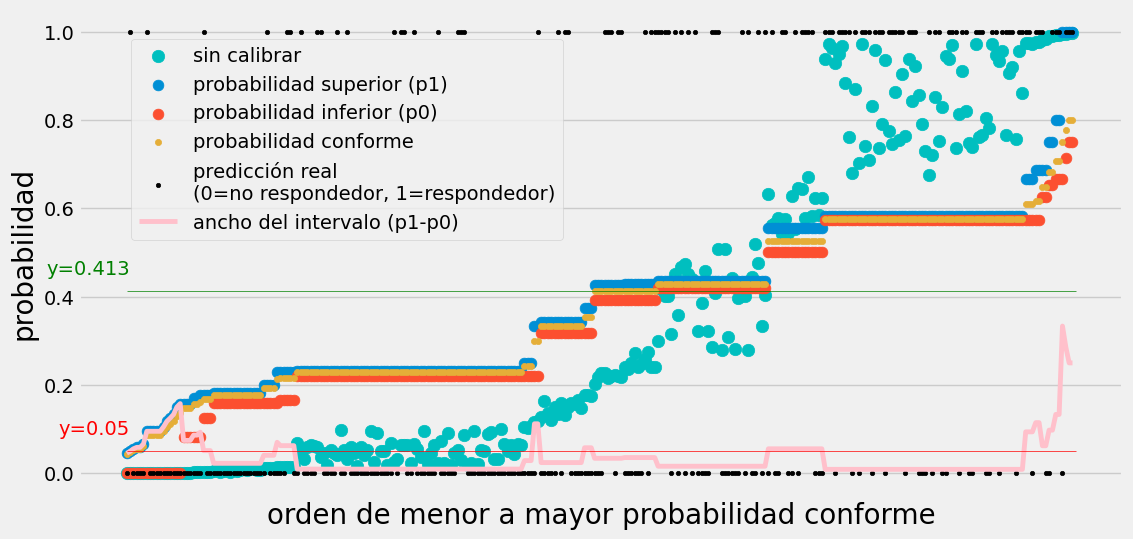

In [41]:
catboost_model_venn_abers_intervals_info = calibration.venn_abers_intervals(
    catboost_model, X_test, y_test, X_cal, y_cal, min_interval_width_filter=0.0, decision_threshold=0.413, point_size=10,
    save_path='./data/figures/catboost_venn_abers_intervals.pdf')

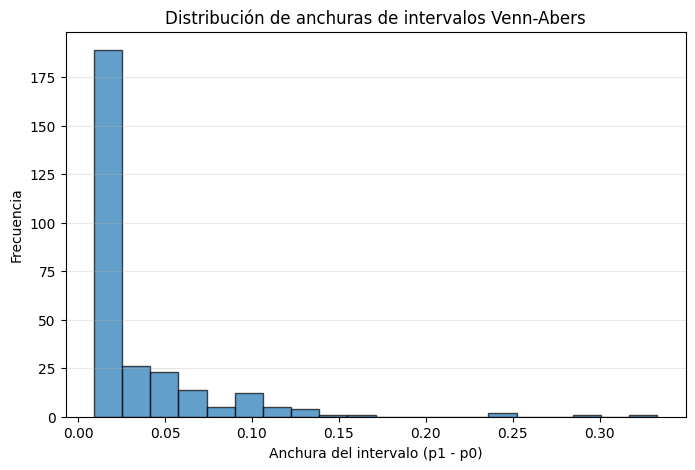

In [32]:
# Histograma de frecuencias de cada ancho de intervalo
plt.figure(figsize=(8, 5))
plt.hist(catboost_model_venn_abers_intervals_info["width"], bins=20, edgecolor='black', alpha=0.7)
plt.xlabel("Anchura del intervalo (p1 - p0)")
plt.ylabel("Frecuencia")
plt.title("Distribución de anchuras de intervalos Venn-Abers")
plt.grid(axis='y', alpha=0.3)
plt.show()

In [33]:
pd.DataFrame(catboost_model_venn_abers_intervals_info["width"]).describe()

,width
count,284.000000
mean,0.033425
std,0.042625
min,0.009091
25%,0.009615
50%,0.016129
75%,0.040909
max,0.333333


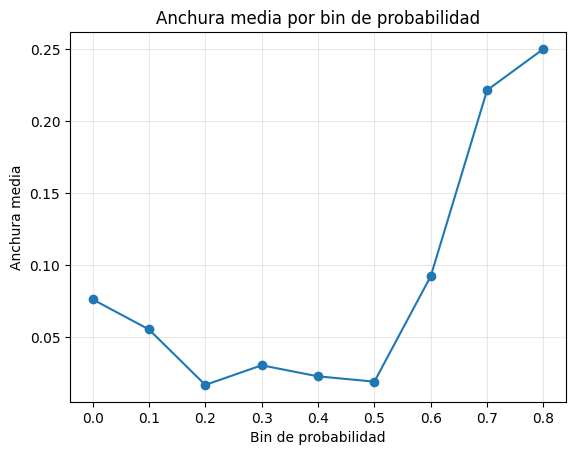

In [34]:
bins = np.linspace(0, 1, 11)
bin_idx = np.digitize(catboost_model_venn_abers_intervals_info["p"], bins)

mean_widths = [catboost_model_venn_abers_intervals_info["width"][bin_idx == i].mean() for i in range(1, len(bins))]

plt.plot(bins[:-1], mean_widths, marker='o')
plt.xlabel("Bin de probabilidad")
plt.ylabel("Anchura media")
plt.title("Anchura media por bin de probabilidad")
plt.grid(alpha=0.3)
plt.show()


Tras el análisis de las métricas de calibración y DCA queda claro que el calibrador más relevante para el caso de uso de este proyecto es Venn-ABBERS así que almacenamos los modelos calibrados con ese calibrador para posteriores pasos

In [35]:
# Metemos los modelos calibrados con Venn-ABERS en un wrapper más o menos scikitlearn compatible para poder pasarle
# directamente los X_test sin tener que primero pasarlos por el modelo base
va_calibrated_logreg_model = calibration.VennAbersClassifier(base_model=logreg_model, va_model=va_logreg_model)
va_calibrated_rf_model = calibration.VennAbersClassifier(base_model=rf_model, va_model=va_rf_model)
va_calibrated_xgboost_model = calibration.VennAbersClassifier(base_model=xgboost_model, va_model=va_xgboost_model)
va_calibrated_catboost_model = calibration.VennAbersClassifier(base_model=catboost_model, va_model=va_catboost_model)

# Guardar los modelos calibrados para usarlos en posteriores análisis
# NOTA: Comentado para evitar guardados de nuevos modelos accidentalmente
#joblib.dump(va_calibrated_logreg_model,   f"./data/best_models/va_calibrated_logreg_model.joblib")
#joblib.dump(va_calibrated_rf_model,       f"./data/best_models/va_calibrated_rf_model.joblib")
#joblib.dump(va_calibrated_xgboost_model,  f"./data/best_models/va_calibrated_xgboost_model.joblib")
#joblib.dump(va_calibrated_catboost_model, f"./data/best_models/va_calibrated_catboost_model.joblib")